In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow.keras import layers, models, applications
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
import os
import cv2
from glob import glob
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# GPU Configuration for T4
import tensorflow as tf

# Check for GPU availability
print("GPU Available: ", tf.test.is_gpu_available())
print("GPU Device Name: ", tf.test.gpu_device_name())

# Set memory growth to avoid OOM errors
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU configured: {gpus}")
    except RuntimeError as e:
        print(e)

# Verify TensorFlow can see the GPU
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    print('GPU device not found')
else:
    print('Found GPU at: {}'.format(device_name))

GPU Available:  True
GPU Device Name:  /device:GPU:0
GPU configured: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Found GPU at: /device:GPU:0


In [4]:
# 1. Imports and basic setup
import os
import pathlib
import json
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow import keras
from tensorflow.keras import layers

# Enable mixed precision for speed on GPU
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

print("TensorFlow version:", tf.__version__)
print("Mixed precision policy:", mixed_precision.global_policy())
print("GPUs:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
Mixed precision policy: <DTypePolicy "mixed_float16">
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
# 2. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# 3. Directories (reuse same root, new dataset)
ROOT_DIR = "/content/drive/MyDrive/Cross-Dataset Generalization Thesis"

UCM_DIR = os.path.join(ROOT_DIR, "uc_merced")
MODELS_DIR = os.path.join(UCM_DIR, "models")
LOGS_DIR = os.path.join(UCM_DIR, "logs")
FIGS_DIR = os.path.join(UCM_DIR, "figs")
METRICS_DIR = os.path.join(UCM_DIR, "metrics")

for d in [ROOT_DIR, UCM_DIR, MODELS_DIR, LOGS_DIR, FIGS_DIR, METRICS_DIR]:
    os.makedirs(d, exist_ok=True)
    print("Ensured directory:", d)

Ensured directory: /content/drive/MyDrive/Cross-Dataset Generalization Thesis
Ensured directory: /content/drive/MyDrive/Cross-Dataset Generalization Thesis/uc_merced
Ensured directory: /content/drive/MyDrive/Cross-Dataset Generalization Thesis/uc_merced/models
Ensured directory: /content/drive/MyDrive/Cross-Dataset Generalization Thesis/uc_merced/logs
Ensured directory: /content/drive/MyDrive/Cross-Dataset Generalization Thesis/uc_merced/figs
Ensured directory: /content/drive/MyDrive/Cross-Dataset Generalization Thesis/uc_merced/metrics


In [7]:
# 4. Load UC Merced via TFDS
DATASET_NAME = "uc_merced"

# TFDS defines only a 'train' split; do custom train/val/test split
(ds_full,), ds_info = tfds.load(
    DATASET_NAME,
    split=["train"],
    with_info=True,
    as_supervised=True
)

num_classes = ds_info.features["label"].num_classes
class_names = ds_info.features["label"].names
print("Classes:", num_classes, class_names)

num_examples = ds_info.splits["train"].num_examples
train_size = int(0.6 * num_examples)
val_size = int(0.2 * num_examples)
test_size = num_examples - train_size - val_size

print("Total:", num_examples)
print("Train/Val/Test:", train_size, val_size, test_size)

ds_train = ds_full.take(train_size)
ds_temp = ds_full.skip(train_size)
ds_val = ds_temp.take(val_size)
ds_test = ds_temp.skip(val_size)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/uc_merced/incomplete.38BNWC_2.0.0/uc_merced-train.tfrecord*...:   0%|     …

Dataset uc_merced downloaded and prepared to /root/tensorflow_datasets/uc_merced/2.0.0. Subsequent calls will reuse this data.
Classes: 21 ['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential', 'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark', 'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt']
Total: 2100
Train/Val/Test: 1260 420 420


Sample images from UC Merced dataset:


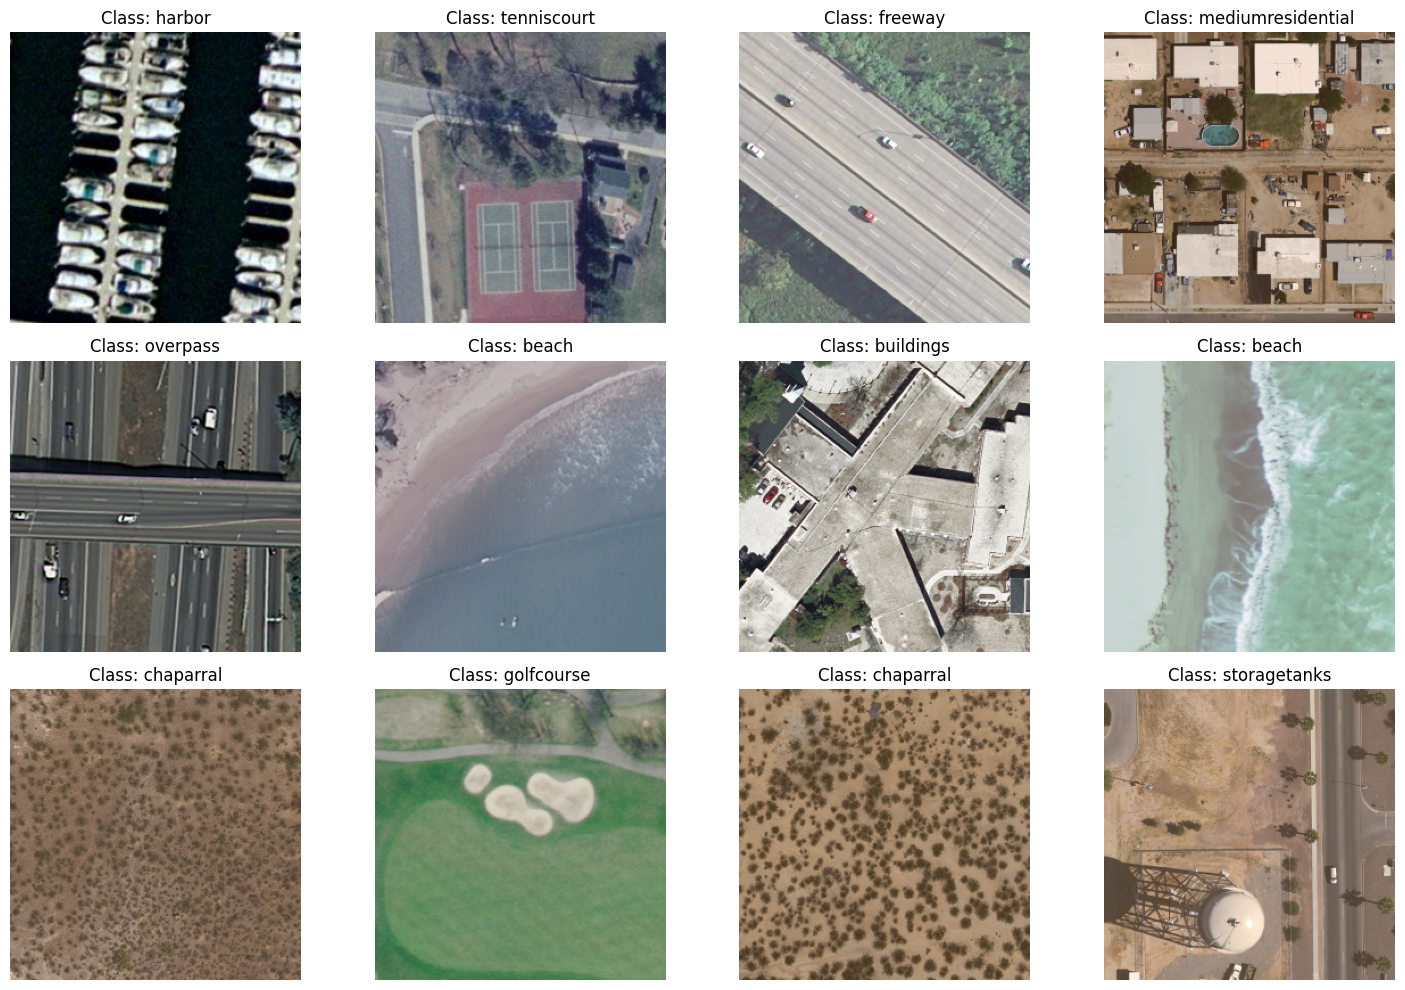

In [8]:
# Visualize sample images from the dataset
def visualize_samples(dataset, class_names, num_samples=12):
    # Take a batch from the dataset and convert to numpy arrays for visualization
    # Batch the dataset before taking a sample to ensure labels is an array
    batched_dataset = dataset.batch(num_samples)
    # The dataset might contain tf.uint8 images after initial load, so ensure float32 for plt.imshow
    images, labels = next(batched_dataset.map(lambda img, lbl: (tf.image.convert_image_dtype(img, tf.float32), lbl)).take(1).as_numpy_iterator())

    plt.figure(figsize=(15, 10))
    for i in range(min(num_samples, len(images))):
        plt.subplot(3, 4, i+1)
        plt.imshow(images[i])
        # Assumes labels are integer labels
        class_idx = labels[i]
        plt.title(f'Class: {class_names[class_idx]}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Display sample images from the original full dataset (before any custom preprocessing or splitting)
print("Sample images from UC Merced dataset:")
visualize_samples(ds_full, class_names)

In [9]:
# 5. Preprocessing and augmentation (same pattern as EuroSAT)
IMG_SIZE = 128
BATCH_SIZE = 64
AUTO = tf.data.AUTOTUNE

def preprocess(image, label, training=False):
    image = tf.image.convert_image_dtype(image, tf.float32)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    if training:
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_flip_up_down(image)
    return image, label

def prepare_ds(ds, training=False):
    if training:
        ds = ds.shuffle(1000, reshuffle_each_iteration=True)
    ds = ds.map(lambda x, y: preprocess(x, y, training=training),
                num_parallel_calls=AUTO)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTO)
    return ds

train_ds = prepare_ds(ds_train, training=True)
val_ds = prepare_ds(ds_val, training=False)
test_ds = prepare_ds(ds_test, training=False)

In [10]:
# 6. DenseNet121 preprocessing
from tensorflow.keras.applications.densenet import (
    DenseNet121,
    preprocess_input as densenet_preprocess,
)

def add_densenet_preprocess(ds):
    def _f(images, labels):
        images = densenet_preprocess(images * 255.0)
        return images, labels
    return ds.map(_f, num_parallel_calls=AUTO)

train_ds = add_densenet_preprocess(train_ds)
val_ds = add_densenet_preprocess(val_ds)
test_ds = add_densenet_preprocess(test_ds)

In [11]:
# 7. Ensure UC Merced class mapping (reuse if already saved)
class_mapping_path = os.path.join(METRICS_DIR, "ucm_class_mapping.json")
if not os.path.exists(class_mapping_path):
    with open(class_mapping_path, "w") as f:
        json.dump({"class_names": class_names}, f, indent=2)
    print("Saved class mapping to:", class_mapping_path)
else:
    print("Class mapping already exists:", class_mapping_path)

Class mapping already exists: /content/drive/MyDrive/Cross-Dataset Generalization Thesis/uc_merced/metrics/ucm_class_mapping.json


In [12]:
# 8. Build DenseNet121 model for UC Merced
base_model = DenseNet121(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    pooling="avg"
)

base_model.trainable = False

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input_layer_ucm_densenet121")
x = base_model(inputs, training=False)
x = layers.Dense(256, activation="relu", name="dense")(x)
x = layers.Dropout(0.3, name="dropout")(x)
outputs = layers.Dense(num_classes, activation="softmax", dtype="float32", name="dense_1")(x)

model = keras.Model(inputs, outputs, name="densenet121_ucm")
model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "densenet121_ucm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_ucm_densenet121     │ (None, 128, 128, 3)    │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 1024)           │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 21)             │         5,397 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,305,301 (27.87 MB)

 Trainable params: 267,797 (1.02 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [13]:
# 9. Compile model
initial_lr = 1e-3
optimizer = keras.optimizers.Adam(learning_rate=initial_lr)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [14]:
# 10. Callbacks
csv_log_path = os.path.join(LOGS_DIR, "ucm_densenet121_history.csv")
checkpoint_path = os.path.join(MODELS_DIR, "ucm_densenet121_best.weights.h5")

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),
    keras.callbacks.CSVLogger(csv_log_path),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    )
]

EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

print("Training complete. History logged to:", csv_log_path)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 874ms/step - accuracy: 0.2435 - loss: 2.9423
Epoch 1: val_accuracy improved from -inf to 0.75000, saving model to /content/drive/MyDrive/Cross-Dataset Generalization Thesis/uc_merced/models/ucm_densenet121_best.weights.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 87s 3s/step - accuracy: 0.2515 - loss: 2.9064 - val_accuracy: 0.7500 - val_loss: 0.9131 - learning_rate: 0.0010
Epoch 2/20
18/20 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.7752 - loss: 0.7991
Epoch 2: val_accuracy improved from 0.75000 to 0.86190, saving model to /content/drive/MyDrive/Cross-Dataset Generalization Thesis/uc_merced/models/ucm_densenet121_best.weights.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 410ms/step - accuracy: 0.7801 - loss: 0.7817 - val_accuracy: 0.8619 - val_loss: 0.4550 - learning_rate: 0.0010
Epoch 3/20
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.8737 - loss: 0.4060
Epoch 3: val_accuracy improved from 0.86190 to 0.90952, saving model to /content/drive/MyDrive/Cross-Data

In [15]:
# 11. Optional fine-tuning
base_model.trainable = True

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=initial_lr * 0.1),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_epochs = 5

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=fine_tune_epochs,
    callbacks=[
        keras.callbacks.CSVLogger(
            os.path.join(LOGS_DIR, "ucm_densenet121_history_ft.csv"), append=True
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=checkpoint_path,
            monitor="val_accuracy",
            save_best_only=True,
            save_weights_only=True,
            verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=2,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=1,
            verbose=1
        )
    ]
)

Epoch 1/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.7651 - loss: 0.8300   
Epoch 1: val_accuracy improved from -inf to 0.90000, saving model to /content/drive/MyDrive/Cross-Dataset Generalization Thesis/uc_merced/models/ucm_densenet121_best.weights.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 447s 10s/step - accuracy: 0.7689 - loss: 0.8182 - val_accuracy: 0.9000 - val_loss: 0.2965 - learning_rate: 1.0000e-04
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.9504 - loss: 0.1769
Epoch 2: val_accuracy improved from 0.90000 to 0.94286, saving model to /content/drive/MyDrive/Cross-Dataset Generalization Thesis/uc_merced/models/ucm_densenet121_best.weights.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 48s 679ms/step - accuracy: 0.9505 - loss: 0.1765 - val_accuracy: 0.9429 - val_loss: 0.1958 - learning_rate: 1.0000e-04
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9797 - loss: 0.0906
Epoch 3: val_accuracy improved from 0.94286 to 0.95238, saving model to /content/drive/MyDrive/Cr

In [16]:
# 13. Evaluate on test set
test_loss, test_acc = model.evaluate(test_ds)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

# 14. Collect predictions for confusion matrix and ROC
y_true = []
y_pred = []
y_score = [] # New list to store all predicted probabilities

for images, labels in test_ds:
    batch_preds = model.predict(images, verbose=0) # Get predictions for current batch
    y_true.extend(labels.numpy().tolist())
    y_pred.extend(np.argmax(batch_preds, axis=-1).tolist())
    y_score.extend(batch_preds.tolist()) # Store raw probabilities

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_score = np.array(y_score) # Convert list of lists to a 2D numpy array

7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 189ms/step - accuracy: 0.9540 - loss: 0.2109
Test loss: 0.21048900485038757
Test accuracy: 0.9452381134033203


In [19]:
print("\n--- Detailed Results ---")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


--- Detailed Results ---
Test Loss: 0.21048900485038757
Test Accuracy: 0.9452381134033203

Classification Report:
                   precision    recall  f1-score   support

     agricultural       1.00      0.92      0.96        24
         airplane       1.00      1.00      1.00        19
  baseballdiamond       1.00      0.92      0.96        26
            beach       1.00      1.00      1.00        19
        buildings       0.88      0.82      0.85        17
        chaparral       1.00      1.00      1.00        21
 denseresidential       0.93      0.64      0.76        22
           forest       1.00      1.00      1.00        30
          freeway       1.00      0.94      0.97        17
       golfcourse       0.94      0.94      0.94        18
           harbor       1.00      1.00      1.00        13
     intersection       0.95      0.95      0.95        20
mediumresidential       0.65      1.00      0.79        17
   mobilehomepark       0.88      1.00      0.93        21

In [20]:
# 15. Confusion matrix and classification report
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix shape:", cm.shape)

report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

# Save metrics for Day 2-5
metrics_path = os.path.join(METRICS_DIR, "ucm_densenet121_confusion_matrix.json")
with open(metrics_path, "w") as f:
    json.dump(
        {
            "test_loss": float(test_loss),
            "test_accuracy": float(test_acc),
            "classification_report": report
        },
        f,
        indent=2
    )
print("Saved metrics to:", metrics_path)

# Save confusion matrix as .npy
cm_path = os.path.join(METRICS_DIR, "ucm_densenet121_confusion_matrix.npy")
np.save(cm_path, cm)
print("Saved confusion matrix to:", cm_path)

Confusion matrix shape: (21, 21)
Saved metrics to: /content/drive/MyDrive/Cross-Dataset Generalization Thesis/uc_merced/metrics/ucm_densenet121_confusion_matrix.json
Saved confusion matrix to: /content/drive/MyDrive/Cross-Dataset Generalization Thesis/uc_merced/metrics/ucm_densenet121_confusion_matrix.npy


In [21]:
# 17. Save full model for reuse in Day 2-5
full_model_path = os.path.join(MODELS_DIR, "ucm_densenet121_full.keras") # Added .keras extension
model.save(full_model_path)
print("Saved full model to:", full_model_path)

Saved full model to: /content/drive/MyDrive/Cross-Dataset Generalization Thesis/uc_merced/models/ucm_densenet121_full.keras


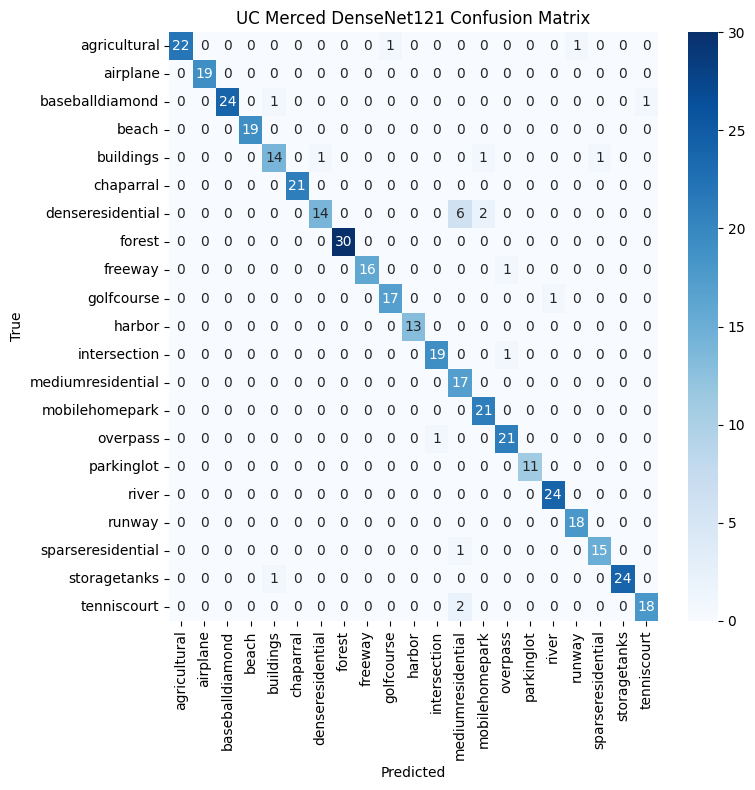

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 10})
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("UC Merced DenseNet121 Confusion Matrix")
plt.tight_layout()
plt.show() # Display the plot directly

In [23]:
# 16. Plot confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure FIGS_DIR is defined, which it is from earlier cells.

plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 10})
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("UC Merced DenseNet121 Confusion Matrix")

fig_path = os.path.join(FIGS_DIR, "ucm_densenet121_confusion_matrix.png")
plt.tight_layout()
plt.savefig(fig_path, dpi=300)
plt.close()
print("Saved confusion matrix figure to:", fig_path)

Saved confusion matrix figure to: /content/drive/MyDrive/Cross-Dataset Generalization Thesis/uc_merced/figs/ucm_densenet121_confusion_matrix.png


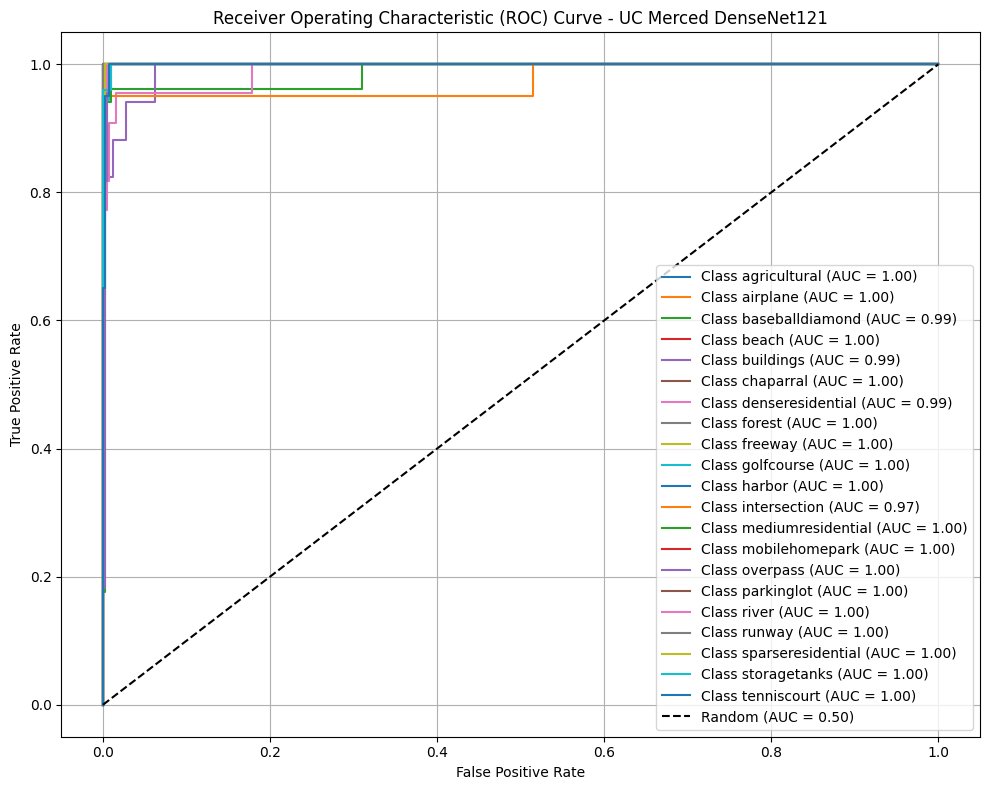

In [24]:
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Convert y_true to one-hot encoding for ROC curve calculation
y_true_one_hot = to_categorical(y_true, num_classes=num_classes)

plt.figure(figsize=(10, 8))

# Calculate ROC curve and AUC for each class
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_one_hot[:, i], y_score[:, i]) # Use y_score instead of preds
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - UC Merced DenseNet121')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

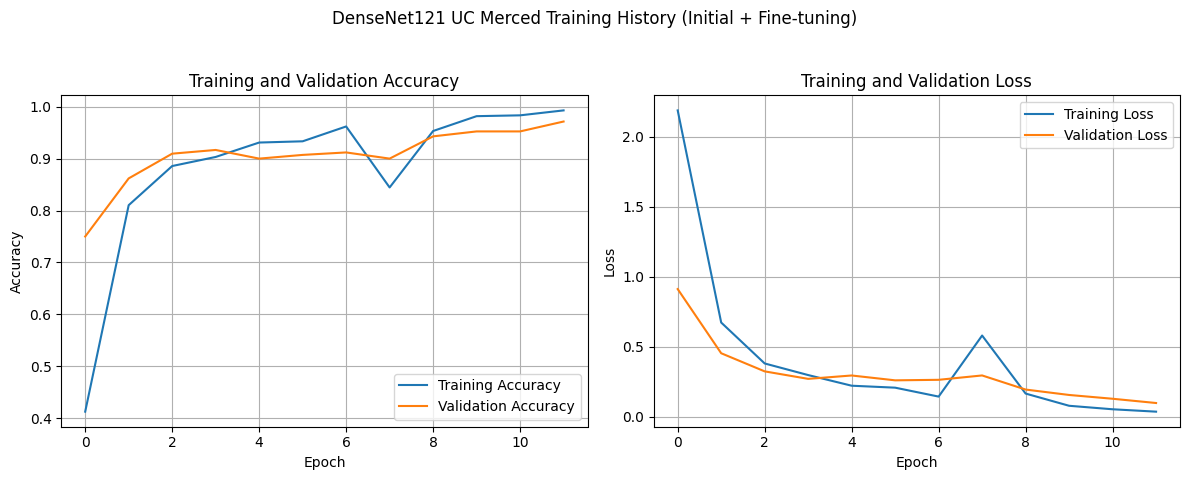

In [25]:
import matplotlib.pyplot as plt

def plot_history(history, history_ft=None, title='Model Training History'):
    acc = history.history.get('accuracy', [])
    val_acc = history.history.get('val_accuracy', [])
    loss = history.history.get('loss', [])
    val_loss = history.history.get('val_loss', [])

    if not acc:
        print("Warning: Training accuracy data not found in history. Cannot plot.")
        return

    epochs_range = range(len(acc))

    if history_ft:
        ft_acc = history_ft.history.get('accuracy', [])
        ft_val_acc = history_ft.history.get('val_accuracy', [])
        ft_loss = history_ft.history.get('loss', [])
        ft_val_loss = history_ft.history.get('val_loss', [])

        acc = acc + ft_acc
        val_acc = val_acc + ft_val_acc
        loss = loss + ft_loss
        val_loss = val_loss + ft_val_loss
        epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    if val_acc:
        plt.plot(epochs_range[:len(val_acc)], val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    if val_loss:
        plt.plot(epochs_range[:len(val_loss)], val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)

    plt.suptitle(title)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Call the function to plot the history
plot_history(history, history_ft, title='DenseNet121 UC Merced Training History (Initial + Fine-tuning)')

In [26]:
print("\n--- Overall Model Metrics ---")
print(f"Accuracy: {test_acc:.4f}")
print(f"Precision (Macro Avg): {report['macro avg']['precision']:.4f}")
print(f"Recall (Macro Avg): {report['macro avg']['recall']:.4f}")
print(f"F1-score (Macro Avg): {report['macro avg']['f1-score']:.4f}")


--- Overall Model Metrics ---
Accuracy: 0.9452
Precision (Macro Avg): 0.9494
Recall (Macro Avg): 0.9470
F1-score (Macro Avg): 0.9446
